In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

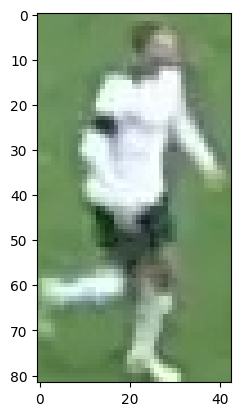

In [ ]:
image_path = 'output_video/cropped_image.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

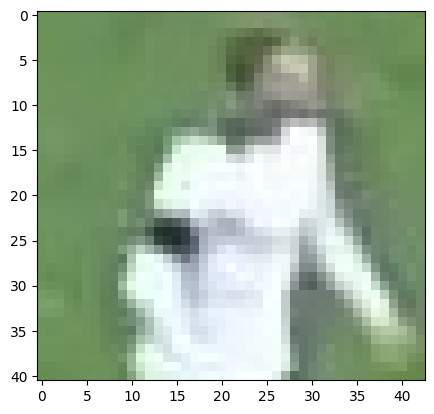

In [19]:
top_half_image = image[0: int(image.shape[0]/2), : ]
plt.imshow(top_half_image)
plt.show()

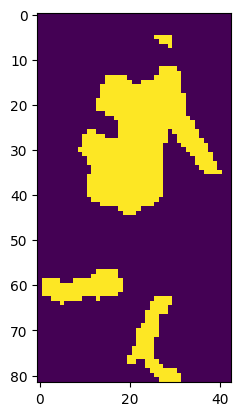

In [21]:
image_2d = image.reshape(-1,3)
#train image by kmeans
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

#label
labels = kmeans.labels_

#reshape image
clustered_image = labels.reshape(image.shape[0], image.shape[1])
plt.imshow(clustered_image)
plt.show()

In [22]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [23]:
player_cluster = 1-non_player_cluster
print(player_cluster)

1


In [24]:
kmeans.cluster_centers_[player_cluster]

array([214.5902965 , 229.52291105, 223.90431267])